## Importing liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Reading Datasets

In [2]:
fg_df=pd.read_csv('/kaggle/input/datasets/dozeradi007/prime-tarde-assignment0-dataset/fear_greed_index.csv')
hist_df=pd.read_csv('/kaggle/input/datasets/dozeradi007/prime-tarde-assignment0-dataset/historical_data.csv')

In [3]:
fg_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
hist_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


### Getting basic information about the datasets

In [5]:
fg_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
hist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

## Cleaning Dataset
### Standardizing Column Names
- `fg_df` already in standard format
- have to perform operation on `hist_df`

In [7]:
hist_df.columns = (
    hist_df.columns
    .str.strip()                      # remove leading/trailing spaces
    .str.lower()                      # lowercase
    .str.replace(' ', '_')            # spaces → underscores
)
hist_df.columns

Index(['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side',
       'timestamp_ist', 'start_position', 'direction', 'closed_pnl',
       'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id',
       'timestamp'],
      dtype='object')

In [8]:
fg_df.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [9]:
hist_df.describe()

,execution_price,size_tokens,size_usd,start_position,closed_pnl,order_id,fee,trade_id,timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


### Checking for NaN

In [10]:
fg_df.isna().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
hist_df.isna().sum()

account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

### Checking for duplicates

In [12]:
fg_df.duplicated().sum()

np.int64(0)

In [13]:
hist_df.duplicated().sum()

np.int64(0)

## Converting Timestamp

In [14]:
hist_df.head()

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [15]:
fg_df['timestamp']=pd.to_datetime(fg_df['timestamp'], unit='s')
hist_df['timestamp']=pd.to_datetime(hist_df['timestamp'], unit='ms')
fg_df.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


In [16]:
fg_df['date']=fg_df['timestamp'].dt.date
hist_df['date']=hist_df['timestamp'].dt.date
fg_df.head()

,timestamp,value,classification,date
0,2018-02-01 05:30:00,30,Fear,2018-02-01
1,2018-02-02 05:30:00,15,Extreme Fear,2018-02-02
2,2018-02-03 05:30:00,40,Fear,2018-02-03
3,2018-02-04 05:30:00,24,Extreme Fear,2018-02-04
4,2018-02-05 05:30:00,11,Extreme Fear,2018-02-05


In [17]:
fg_df['date'].value_counts()

date
2025-05-02    1
2018-02-01    1
2018-02-02    1
2018-02-03    1
2025-04-16    1
             ..
2018-02-09    1
2018-02-08    1
2018-02-07    1
2018-02-06    1
2018-02-05    1
Name: count, Length: 2644, dtype: int64

In [18]:
hist_df['date'].value_counts()

date
2025-02-19    133871
2024-10-27     35241
2025-06-15     26961
2024-07-03      7141
2024-03-09      6962
2023-11-14      1045
2023-03-28         3
Name: count, dtype: int64

- sorting based on timestamp for open and close value

In [19]:
fg_df.sort_values('timestamp', inplace=True)
hist_df.sort_values('timestamp', inplace=True)

In [20]:
daily_fg_df=fg_df.groupby('date').agg(
    fear_greed_value=('value','mean')
).reset_index()
daily_hist_df=hist_df.groupby('date').agg(
    open =('execution_price','first'),
    close=('execution_price', 'last'),
    high=('execution_price', 'max'),
    low=('execution_price','min'),
    volume=('size_usd','sum'), # I use size_usd to measure volume
    net_pnl=("closed_pnl", "sum")
).reset_index()

In [21]:
daily_hist_df

,date,open,close,high,low,volume,net_pnl
0,2023-03-28,1898.60000,1897.9000,1898.6,1897.900000,4.770000e+02,0.000000e+00
1,2023-11-14,0.44868,45984.0000,47063.0,0.084411,1.155543e+07,1.555034e+02
2,2024-03-09,2.84370,2293.5000,70669.0,0.000895,3.940677e+07,1.769655e+05
3,2024-07-03,0.72968,4.9905,71764.0,0.000010,2.184323e+07,1.587424e+05
4,2024-10-27,3417.80000,14.7790,107320.0,0.000005,1.039478e+08,3.189461e+06
5,2025-02-19,127.35000,357.3500,109004.0,0.000094,7.041585e+08,6.699925e+06
6,2025-06-15,0.86300,1.1010,95634.0,0.002093,3.102753e+08,7.170935e+04


### Now merge the datasets

In [22]:
merged_df=pd.merge(daily_hist_df, daily_fg_df, on='date', how='inner')
merged_df

,date,open,close,high,low,volume,net_pnl,fear_greed_value
0,2023-03-28,1898.60000,1897.9000,1898.6,1897.900000,4.770000e+02,0.000000e+00,59.0
1,2023-11-14,0.44868,45984.0000,47063.0,0.084411,1.155543e+07,1.555034e+02,69.0
2,2024-03-09,2.84370,2293.5000,70669.0,0.000895,3.940677e+07,1.769655e+05,84.0
3,2024-07-03,0.72968,4.9905,71764.0,0.000010,2.184323e+07,1.587424e+05,50.0
4,2024-10-27,3417.80000,14.7790,107320.0,0.000005,1.039478e+08,3.189461e+06,74.0
5,2025-02-19,127.35000,357.3500,109004.0,0.000094,7.041585e+08,6.699925e+06,44.0


## Finding Key Metrics
### Daily PnL per trader

In [23]:
daily_pnl=hist_df.groupby(["date", "account"]).agg(
    gross_pnl=("closed_pnl", "sum"),
    total_fees=("fee", "sum")
).reset_index()
daily_pnl["net_pnl"] = daily_pnl["gross_pnl"] - daily_pnl["total_fees"]
daily_pnl.head()

,date,account,gross_pnl,total_fees,net_pnl
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.000000
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,11.072126,-11.072126
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,2783.498528,-2627.995171
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,3.902580,-5567.918720
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,253.106010,-253.106010


### Win Rate & Average Trade Size

In [24]:
orders = hist_df.groupby(["account", "order_id"]).agg(
    pnl=("closed_pnl", "sum"),
    size_usd=("size_usd", "sum"),
    side=("side", "first"),
    direction=("direction", "first"),
    date=("date", "first")
).reset_index()

# Win rate per account
def win_rate(x):
    closed = x[x["pnl"] != 0]  # exclude flat/open trades
    return (closed["pnl"] > 0).sum() / len(closed) if len(closed) > 0 else None

win_stats = orders.groupby("account").apply(
    lambda x: pd.Series({
        "win_rate": win_rate(x),
        "avg_trade_size_usd": x["size_usd"].mean(),
        "avg_win": x.loc[x["pnl"] > 0, "pnl"].mean(),
        "avg_loss": x.loc[x["pnl"] < 0, "pnl"].mean(),
        "profit_factor": x.loc[x["pnl"] > 0, "pnl"].sum() /abs(x.loc[x["pnl"] < 0, "pnl"].sum()) 
        if x.loc[x["pnl"] < 0, "pnl"].sum() != 0 else None
    })
).reset_index()

/tmp/ipykernel_16/1799222340.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  win_stats = orders.groupby("account").apply(


In [25]:
win_stats.head(8)

,account,win_rate,avg_trade_size_usd,avg_win,avg_loss,profit_factor
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.725000,693227.685056,70058.802279,-39225.040556,4.708739
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.671990,8797.871096,166.359727,-161.473596,2.110682
2,0x271b280974205ca63b716753467d5a371de622ab,0.708738,133360.001654,861.979991,-4445.357688,0.471837
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.872706,661.027402,37.518335,-58.324178,4.410183
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.815789,20013.543701,582.485905,-170.180363,15.157921
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.529412,9526.364865,1135.016215,-2056.983242,0.620760
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,0.566434,71047.005868,2921.612260,-3583.768932,1.065064
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,1.000000,28597.411500,3343.515453,NaN,NaN


### Leverage Distribution

In [26]:
denominator = hist_df["start_position"] * hist_df["execution_price"]

hist_df["implied_leverage"] = hist_df["size_usd"] / denominator

# Handle division by zero AFTER
hist_df.loc[denominator == 0, "implied_leverage"] = float("nan")

lev_dist = hist_df.groupby("account")["implied_leverage"].agg(
    avg_lev="mean",
    median_lev="median",
    max_lev="max"
)
lev_dist.head()

,avg_lev,median_lev,max_lev
account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,-0.089250,-0.001052,3.911300e+00
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,14566.867364,0.009874,1.009808e+08
0x271b280974205ca63b716753467d5a371de622ab,-0.092225,-0.003863,1.000002e+00
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,4.301721,0.009753,2.193802e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd,0.912952,0.027947,1.159167e+03


In [27]:
hist_df["implied_leverage"]

83771     0.403130
83770     0.852137
83769          NaN
39280     0.401021
39641     0.235675
            ...   
57688     0.006252
57689     0.006069
57690     0.066739
193299   -0.610214
211223    1.000003
Name: implied_leverage, Length: 211224, dtype: float64

### Number of Trades per Day

In [28]:
# At fill level
fills_per_day = hist_df.groupby(["date", "account"]).size().reset_index(name="fill_count")

# At order level (more meaningful)
orders_per_day = orders.groupby(["date", "account"]).size().reset_index(name="order_count")

### Long/short Ratio

In [29]:
hist_df['direction'].value_counts()

direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Settlement                       1
Liquidated Isolated Short        1
Name: count, dtype: int64

In [30]:
# Keeping only opening positions
open_trades = hist_df[hist_df["direction"].isin(["Open Long", "Open Short"])]

ls = open_trades.groupby(["date", "direction"]).agg(
    order_count=("order_id", "nunique")
).unstack(fill_value=0).reset_index()

ls.columns = ["date", "Open Long", "Open Short"]
ls["long_short_ratio"] = ls["Open Long"] / ls["Open Short"].replace(0, pd.NA)

### Putting all in one DataFrame

In [31]:
account_metrics = win_stats.merge(
    lev_dist.reset_index(), on="account", how="left"
)
account_metrics.head()

,account,win_rate,avg_trade_size_usd,avg_win,avg_loss,profit_factor,avg_lev,median_lev,max_lev
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.725000,693227.685056,70058.802279,-39225.040556,4.708739,-0.089250,-0.001052,3.911300e+00
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.671990,8797.871096,166.359727,-161.473596,2.110682,14566.867364,0.009874,1.009808e+08
2,0x271b280974205ca63b716753467d5a371de622ab,0.708738,133360.001654,861.979991,-4445.357688,0.471837,-0.092225,-0.003863,1.000002e+00
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.872706,661.027402,37.518335,-58.324178,4.410183,4.301721,0.009753,2.193802e+04
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.815789,20013.543701,582.485905,-170.180363,15.157921,0.912952,0.027947,1.159167e+03


In [32]:
trader_daily = daily_pnl.merge(
    orders_per_day, on=["account", "date"], how="left"
)
# market sentiment (Fear & Greed)
trader_daily = trader_daily.merge(
    merged_df[['date', 'fear_greed_value']], on="date", how="left"
)
# long/short ratio
trader_daily = trader_daily.merge(
    ls[['date', 'long_short_ratio']], on="date", how="left"
)
trader_daily.head()

,date,account,gross_pnl,total_fees,net_pnl,order_count,fear_greed_value,long_short_ratio
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.000000,1,59.0,<NA>
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,11.072126,-11.072126,1,69.0,2.122449
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,2783.498528,-2627.995171,302,69.0,2.122449
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,3.902580,-5567.918720,5,84.0,1.529801
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,253.106010,-253.106010,13,84.0,1.529801


In [33]:
final_df = trader_daily.merge(
    account_metrics, on="account", how="left"
)
final_df.head()

,date,account,gross_pnl,total_fees,net_pnl,order_count,fear_greed_value,long_short_ratio,win_rate,avg_trade_size_usd,avg_win,avg_loss,profit_factor,avg_lev,median_lev,max_lev
0,2023-03-28,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,0.000000,0.000000,1,59.0,<NA>,0.529412,9526.364865,1135.016215,-2056.983242,0.620760,19338.480984,0.002810,1.562500e+07
1,2023-11-14,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000,11.072126,-11.072126,1,69.0,2.122449,0.529412,9526.364865,1135.016215,-2056.983242,0.620760,19338.480984,0.002810,1.562500e+07
2,2023-11-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,155.503357,2783.498528,-2627.995171,302,69.0,2.122449,0.689552,32931.604677,4771.543660,-293.608525,36.096815,1.302081,-0.000032,1.633525e+04
3,2024-03-09,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-5564.016140,3.902580,-5567.918720,5,84.0,1.529801,0.529412,9526.364865,1135.016215,-2056.983242,0.620760,19338.480984,0.002810,1.562500e+07
4,2024-03-09,0x430f09841d65beb3f27765503d0f850b8bce7713,0.000000,253.106010,-253.106010,13,84.0,1.529801,1.000000,54927.948519,26033.867021,NaN,NaN,0.037650,0.001722,6.317258e+00


## Analysis part

In [34]:
final_df.corr(numeric_only=True)

,gross_pnl,total_fees,net_pnl,order_count,fear_greed_value,win_rate,avg_trade_size_usd,avg_win,avg_loss,profit_factor,avg_lev,median_lev,max_lev
gross_pnl,1.000000,0.253882,0.999739,0.031561,-0.147659,0.012780,0.190729,0.290958,-0.270465,0.182165,-0.047304,-0.060835,-0.055772
total_fees,0.253882,1.000000,0.231717,0.024260,-0.286317,0.066388,0.656702,0.035632,-0.278779,0.030143,-0.067738,0.010245,-0.073992
net_pnl,0.999739,0.231717,1.000000,0.031169,-0.143205,0.011285,0.176311,0.291786,-0.265429,0.182482,-0.045976,-0.061426,-0.054344
order_count,0.031561,0.024260,0.031169,1.000000,-0.147448,-0.005034,-0.128833,-0.207872,0.223910,0.050633,-0.068462,-0.082063,-0.081872
fear_greed_value,-0.147659,-0.286317,-0.143205,-0.147448,1.000000,-0.019456,-0.028090,0.017480,-0.011285,-0.123987,-0.004151,0.043226,-0.004957
win_rate,0.012780,0.066388,0.011285,-0.005034,-0.019456,1.000000,0.029986,-0.068654,0.058538,0.224185,0.203979,0.429463,0.208106
avg_trade_size_usd,0.190729,0.656702,0.176311,-0.128833,-0.028090,0.029986,1.000000,0.293437,-0.483258,-0.042403,-0.061583,-0.057496,-0.065283
avg_win,0.290958,0.035632,0.291786,-0.207872,0.017480,-0.068654,0.293437,1.000000,-0.748394,-0.040876,-0.084961,-0.104246,-0.089961
avg_loss,-0.270465,-0.278779,-0.265429,0.223910,-0.011285,0.058538,-0.483258,-0.748394,1.000000,0.095641,0.120929,-0.025134,0.136838
profit_factor,0.182165,0.030143,0.182482,0.050633,-0.123987,0.224185,-0.042403,-0.040876,0.095641,1.000000,0.018516,-0.035332,0.012225


### Create sentiment buckets

In [35]:
final_df['sentiment'] = final_df['fear_greed_value'].apply(
    lambda x: 'Fear' if x < 50 else 'Greed'
)
final_df['sentiment'].head()

0    Greed
1    Greed
2    Greed
3    Greed
4    Greed
Name: sentiment, dtype: object

### Compare performance

In [36]:
perf_compare = final_df.groupby('sentiment').agg({
    'net_pnl': 'mean',
    'account': 'nunique'
}).rename(columns={'account': 'num_traders'})
perf_compare

,net_pnl,num_traders
sentiment,,
Fear,204840.848342,32
Greed,49945.629656,31


In [37]:
drawdown = final_df.groupby(['account', 'sentiment'])['net_pnl'].min().reset_index()
drawdown_compare = drawdown.groupby('sentiment')['net_pnl'].mean()
drawdown_compare

sentiment
Fear     204840.848342
Greed    -27466.060377
Name: net_pnl, dtype: float64

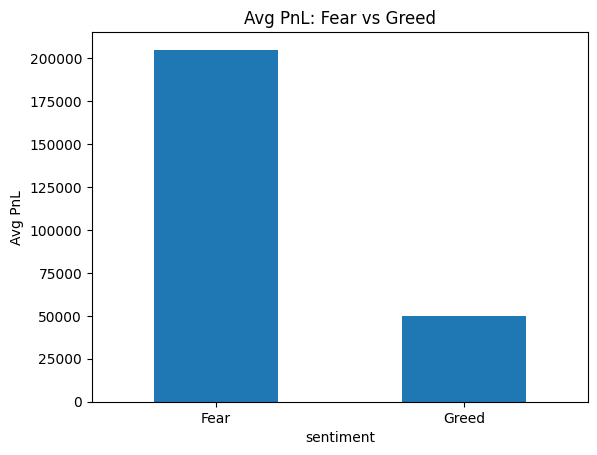

In [38]:
final_df.groupby('sentiment')['net_pnl'].mean().plot(kind='bar')
plt.title("Avg PnL: Fear vs Greed")
plt.xticks(rotation=0)
plt.ylabel('Avg PnL')
plt.show()

### Behavior Change by Sentiment

In [39]:
freq = final_df.groupby('sentiment')['order_count'].mean()
lev = final_df.groupby('sentiment')['avg_lev'].mean()
ls = final_df.groupby('sentiment')['long_short_ratio'].mean()
size = final_df.groupby('sentiment')['avg_trade_size_usd'].mean()

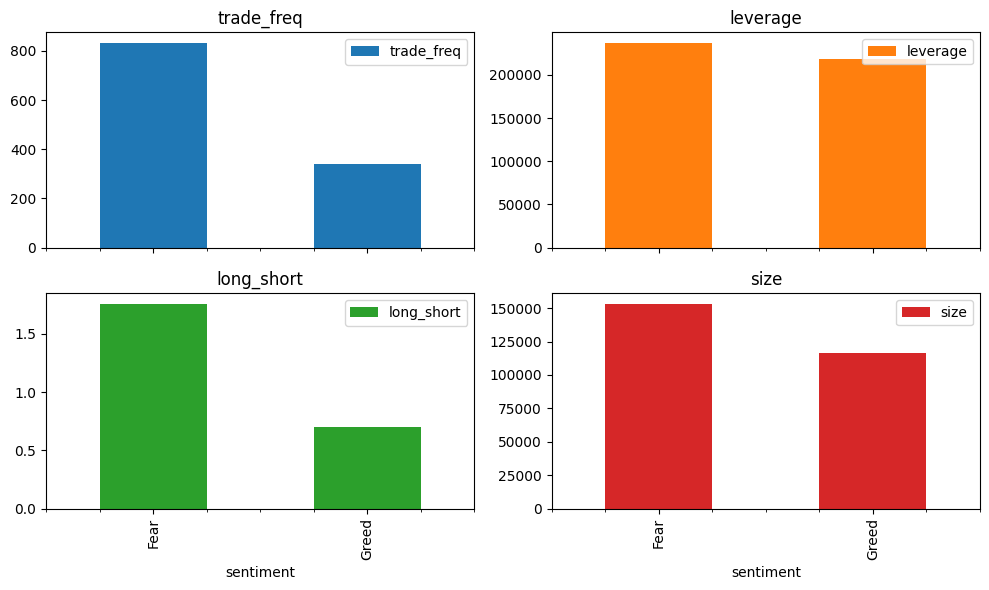

In [40]:
behavior = pd.DataFrame({
    'trade_freq': freq,
    'leverage': lev,
    'long_short': ls,
    'size': size
})

behavior.plot(kind='bar', subplots=True, layout=(2,2), figsize=(10,6))
plt.tight_layout()
plt.show()

### Segmentation

In [41]:
final_df['lev_group'] = pd.qcut(final_df['median_lev'], 2, labels=['Low Lev', 'High Lev'])

In [42]:
trader_freq = final_df.groupby('account')['order_count'].mean()
freq_group = pd.qcut(trader_freq, 2, labels=['Low Freq', 'High Freq'])

final_df = final_df.merge(freq_group.rename('freq_group'), on='account')

In [43]:
pnl_std = final_df.groupby('account')['net_pnl'].std()
consistency = pd.qcut(pnl_std, 2, labels=['Consistent', 'Inconsistent'])

final_df = final_df.merge(consistency.rename('consistency'), on='account')

In [44]:
segment_analysis = final_df.groupby(['lev_group', 'freq_group']).agg({
    'net_pnl': 'mean',
    'order_count': 'mean'
})

/tmp/ipykernel_16/2505991701.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = final_df.groupby(['lev_group', 'freq_group']).agg({


### How profitability changes with trading frequency + leverage behavior

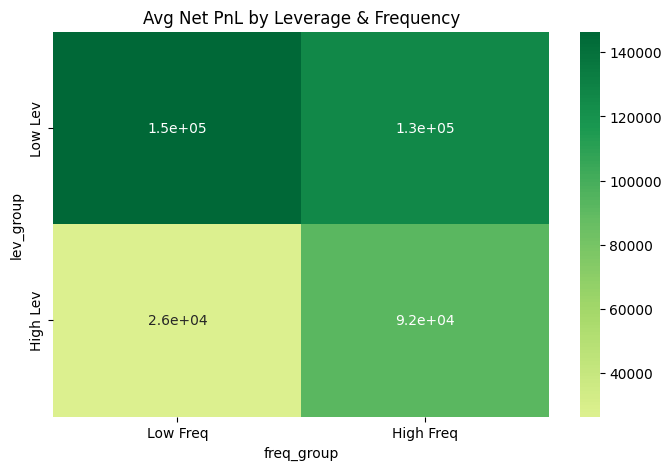

In [45]:
pivot = segment_analysis['net_pnl'].unstack()

plt.figure(figsize=(8,5))
sns.heatmap(pivot, annot=True, cmap="RdYlGn", center=0)
plt.title("Avg Net PnL by Leverage & Frequency")
plt.show()

/tmp/ipykernel_16/2539832085.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lev_pnl = final_df.groupby('lev_group').agg({
/tmp/ipykernel_16/2539832085.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  final_df.groupby('lev_group')['net_pnl'].mean().plot(kind='bar')


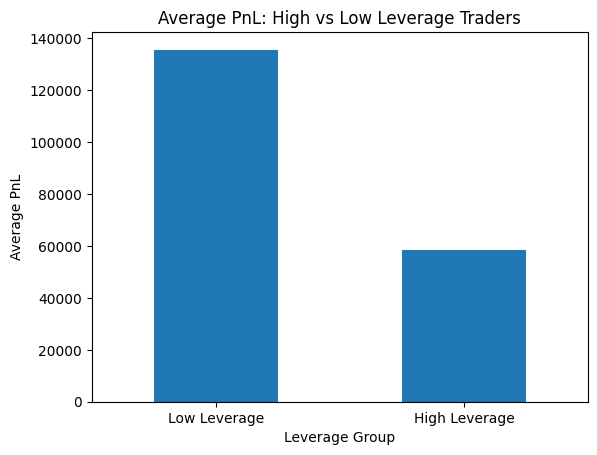

In [46]:
final_df['lev_group'] = pd.qcut(
    final_df['median_lev'], 
    2, 
    labels=['Low Leverage', 'High Leverage']
)

lev_pnl = final_df.groupby('lev_group').agg({
    'net_pnl': ['mean', 'median', 'std'],
    'account': 'nunique'
})

lev_pnl.columns = ['avg_pnl', 'median_pnl', 'pnl_volatility', 'num_traders']
lev_pnl = lev_pnl.reset_index()

final_df.groupby('lev_group')['net_pnl'].mean().plot(kind='bar')
plt.title("Average PnL: High vs Low Leverage Traders")
plt.ylabel("Average PnL")
plt.xlabel("Leverage Group")
plt.xticks(rotation=0)
plt.show()

## Trading Behavior Insights

### Insight 1: Sentiment vs Profitability
Fear periods show higher average PnL in the observed dataset compared to Greed periods.

---

### Insight 2: Risk Behavior
Trading activity (frequency and position size) increases during Fear, indicating higher market participation and risk exposure. 


---

### Insight 3: High Leverage ≠ Better Performance
Higher leverage is associated with weaker average performance across most segments, suggesting reduced strategy stability. 

This suggests that **increased risk does not necessarily translate to better returns**.

---

### Insight 4: Consistency Over Frequency
Consistent traders outperform high-frequency traders when evaluated on a **risk-adjusted basis**, highlighting the importance of discipline over activity level.

## Actionable output

### 1. Prioritize low leverage
  - During all market conditions:
    - Maintain low leverage as default
    - Avoid aggressive scaling of exposure
    - Use leverage only in high-confidence setups

### 2. Selective Trading Over High Frequency
  - Across all regimes:
    - Focus on trade quality rather than trade quantity
    - Avoid overtrading in low-edge conditions

### 3. Fear Regime Opportunity Management
  - During Fear periods:
    - Increase selectivity, not risk
    - Keep position sizing controlled
    - Avoid compounding leverage with volatility

### 4. Greed Regime Capital Preservation
  - During Greed periods:
    - Reduce unnecessary trading activity
    - Prioritize consistency over expansion
    - Maintain disciplined risk exposure